En este trabajo se estudia el problema de contorno dado por:
		$$\epsilon \frac{\partial T(x,t)}{\partial t}=\frac{\partial^2 T(x,t)}{\partial x^2}-\sigma^2 \left((T(x,t)\right) T(x,t)+f(x) \ , \ 0<x<L \ , \ 0<t<t_{max}$$
		$$\frac{\partial T(0,t)}{\partial x}=\beta T(0)-\gamma $$
		$$T(L,t)=\delta \ , \ 0<t<t_{max} $$
		$$f(x)=F_0 e^{-\mu x} \ , \ 0<t<t_{max}$$
La parte espacial se discretiza mediante diferencias finitas de segundo orden. La condició de Robin se discretiza con la ayuda del nodo fantasma. La integración temporal se realiza mediante el métod de Crank-Nicolson.

  Activating project at `~/Desktop/Codi/TFM/ProvesEDOs`


          BANCO DE PRUEBAS PARA EL TFM (BARRA TÉRMICA)      
▶ Evaluando: Tsit5 (Explícito)...
  └─ Pasos adaptativos: 1145
  └─ Tiempo de cómputo: 49.68 ms
------------------------------------------------------------
▶ Evaluando: Rosenbrock23 (Implícito)...
  └─ Pasos adaptativos: 125
  └─ Tiempo de cómputo: 67.43 ms
------------------------------------------------------------
▶ Evaluando: Rodas5P (Rosenbrock - Orden 5)...
  └─ Pasos adaptativos: 42
  └─ Tiempo de cómputo: 292.33 ms
------------------------------------------------------------
▶ Evaluando: AutoTsit5(Rosenbrock23)...
  └─ Pasos adaptativos: 111
  └─ Tiempo de cómputo: 59.54 ms
------------------------------------------------------------


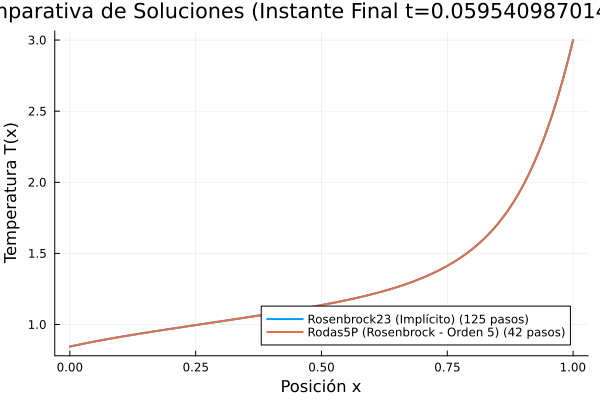

In [3]:
# ==========================================
# PREPARACIÓN DEL ENTORNO
# ==========================================

using Pkg
cd("/home/antonibancells/Desktop/Codi/TFM/ProvesEDOs")
Pkg.activate(".")
using Plots
using LinearAlgebra
using DifferentialEquations, OrdinaryDiffEq

function simular_transitorio_sciml()
    # =================================================================
    # PARÁMETROS GEOMÉTRICOS, FRONTERAS Y PARAMETRIZACIÓN NO LINEAL
    # =================================================================
    L, β, γ, δ = 1.0, 1.5, 0.5, 3.0
    F0, μ = 10.0, 1.0
    
    σ2_min, σ2_max = 2.0^2, 6.0^2  
    Tc, k_sig = 1.6, 5.0     
    calcular_σ2(T) = σ2_min + (σ2_max - σ2_min) / (1.0 + exp(-k_sig * (T - Tc)))

    N = 100
    dx = L / N
    x_nodos = collect(0:dx:L)
    f(x) = F0 * exp(-μ * x)

    t_final = 0.1
    tspan = (0.0, t_final)

    # Condición inicial: rampa compatible
    T_inicial = [ (i-1)*dx * (δ/L) for i in 1:N ]

    # =================================================================
    # DEFINICIÓN DEL SISTEMA DINÁMICO dT/dt = G(T, p, t)
    # =================================================================
    function sistema_edo_termico!(dT, T, p, t)
        σ2_local = calcular_σ2.(T)
        
        # Nodo i = 1 (Robin) -> Corresponde a dT = A*T - b
        dT[1] = -(1/dx^2 + β/dx + σ2_local[1]/2)*T[1] + (1/dx^2)*T[2] - (-f(0)/2 - γ/dx)

        # Nodos internos (i = 2 hasta N-1)
        for i in 2:N-1
            dT[i] = (1/dx^2)*T[i-1] - (2/dx^2 + σ2_local[i])*T[i] + (1/dx^2)*T[i+1] - (-f((i-1)*dx))
        end

        # Nodo i = N (Dirichlet)
        dT[N] = (1/dx^2)*T[N-1] - (2/dx^2 + σ2_local[N])*T[N] - (-f((N-1)*dx) - (1/dx^2) * δ)
    end

    # Creamos el problema matemático
    prob = ODEProblem(sistema_edo_termico!, T_inicial, tspan)

    # =================================================================
    # BANCO DE PRUEBAS: SELECCIÓN DE MÉTODOS
    # =================================================================
    metodos = [
        ("Tsit5 (Explícito)", Tsit5()),
        ("Rosenbrock23 (Implícito)", Rosenbrock23()),
        ("Rodas5P (Rosenbrock - Orden 5)", Rodas5P()),
        ("AutoTsit5(Rosenbrock23)", AutoTsit5(Rosenbrock23()))
    ]

    println("="^60)
    println("          BANCO DE PRUEBAS PARA EL TFM (BARRA TÉRMICA)      ")
    println("="^60)

    # Guardaremos aquí los resultados para comparar al final
    resultados = []

    for (nombre, algoritmo) in metodos
        println("▶ Evaluando: $nombre...")
        
        # Primera ejecución (Precompilación JIT oculta)
        solve(prob, algoritmo, reltol=1e-6, abstol=1e-6, save_everystep=false)
        
        # Segunda ejecución: Medición real de tiempo y pasos
        t_inicio = time()
        sol = solve(prob, algoritmo, reltol=1e-6, abstol=1e-6)
        t_final = time() - t_inicio
        
        pasos = length(sol.t)
        
        push!(resultados, (nombre, sol, pasos, t_final))
        
        println("  └─ Pasos adaptativos: $pasos")
        println("  └─ Tiempo de cómputo: $(round(t_final * 1000, digits=2)) ms")
        println("-"^60)
    end

    # =================================================================
    # GRAFICACIÓN COMPARATIVA FINAL
    # =================================================================
    # Gráfica para ver que todos los métodos implícitos convergen a la misma física
    p_comp = plot(grid=true, title="Comparativa de Soluciones (Instante Final t=$t_final)", 
                  xlabel="Posición x", ylabel="Temperatura T(x)", legend=:bottomright)
    
    for (nombre, sol, pasos, t_comp) in resultados
        # Excluimos Tsit5 de la gráfica si da problemas o satura la leyenda
        if !occursin("Tsit5", nombre)
            # Extraemos la solución en el último instante de tiempo t_final
            T_perfil_final = [sol(t_final); δ]
            plot!(p_comp, x_nodos, T_perfil_final, lw=2, label="$nombre ($pasos pasos)")
        end
    end
    
    display(p_comp)
end

simular_transitorio_sciml()